### Fig. 5(a)-(c): finite-size ratio comparison, old vs. new partition

- **(a)** old partition — renyi (bipartite) and multi (tripartite), $\beta=0.05$
- **(b)** renyi (bipartite) uses the *new*-partition files; multi (tripartite) stays on the *old*-partition files
- **(c)** both renyi and multi use the *new*-partition files

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
beta = 0.05
V_list = [12, 15, 17]

In [3]:
# Each V gets its own hue; bipartite = dark shade, tripartite = light shade
# of that same hue.
import colorsys
import matplotlib.colors as mcolors

V_BASE_COLOR = {
    12: "tab:orange",
    15: "tab:green",
    17: "tab:blue",
}

DARK_LIGHTNESS  = 0.2   # bipartite (darker)
LIGHT_LIGHTNESS = 0.7   # tripartite (lighter)


def set_lightness(color, target_l):
    """Return `color` with its HLS lightness set to `target_l` (hue/saturation kept)."""
    h, l, s = colorsys.rgb_to_hls(*mcolors.to_rgb(color))
    return colorsys.hls_to_rgb(h, target_l, s)


color_bipartite_dict  = {V: set_lightness(c, DARK_LIGHTNESS)  for V, c in V_BASE_COLOR.items()}
color_tripartite_dict = {V: set_lightness(c, LIGHT_LIGHTNESS) for V, c in V_BASE_COLOR.items()}

# Change marker by V
marker_dict = {
    12: "o",   # circle
    15: "^",   # triangle
    17: "s",   # square
}

# ── Font sizes ────────────────────────────────────────────────────────────────
LABEL_FONTSIZE  = 28
TICK_FONTSIZE   = 24
LEGEND_FONTSIZE = 14
PANEL_FONTSIZE  = 28

In [4]:
# Panel definitions: which partition ("" = old, "_new_partition" = new) each
# entropy type uses in each panel, plus the explicit (V_A, V_B[, V_C]) used
# for each V shown in the legend instead of the caption text.
PANEL_CONFIGS = [
    dict(
        letter="a",
        renyi_suffix="", multi_suffix="",
        bipartite_partition={12: (6, 6), 15: (7, 8), 17: (8, 9)},
        tripartite_partition={12: (4, 4, 4), 15: (5, 5, 5), 17: (5, 6, 6)},
    ),
    dict(
        letter="b",
        renyi_suffix="_new_partition", multi_suffix="",
        bipartite_partition={12: (4, 8), 15: (5, 10), 17: (6, 11)},
        tripartite_partition={12: (4, 4, 4), 15: (5, 5, 5), 17: (5, 6, 6)},
    ),
    dict(
        letter="c",
        renyi_suffix="_new_partition", multi_suffix="_new_partition",
        bipartite_partition={12: (4, 8), 15: (5, 10), 17: (6, 11)},
        tripartite_partition={12: (4, 3, 5), 15: (5, 4, 6), 17: (6, 4, 7)},
    ),
]

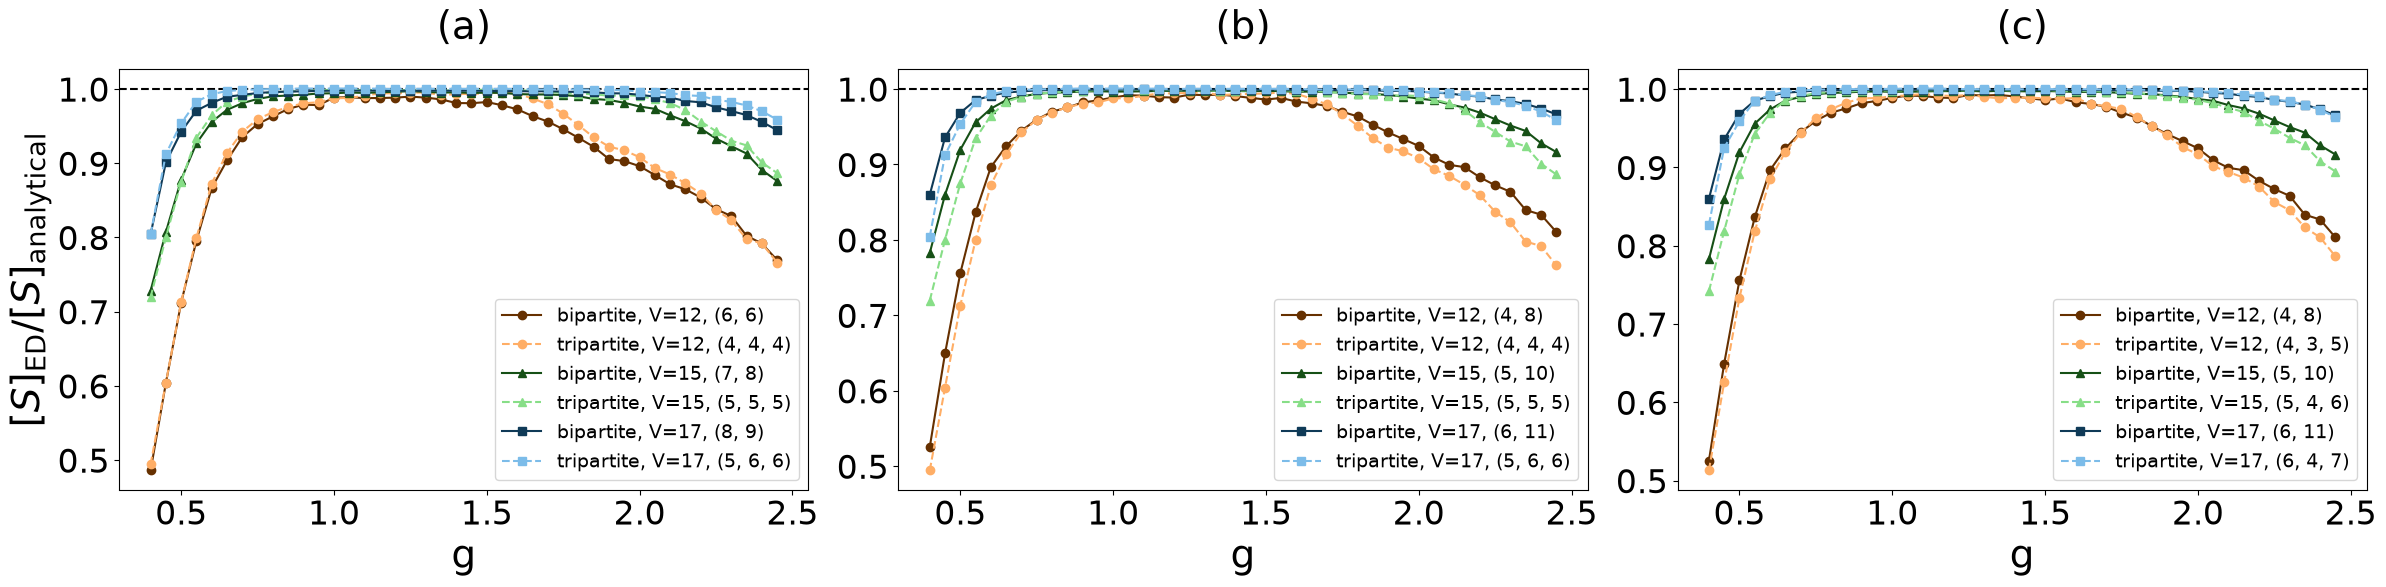

In [5]:
BASE_DIR = Path(".")

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for ax, cfg in zip(axes, PANEL_CONFIGS):
    renyi_suffix = cfg["renyi_suffix"]
    multi_suffix = cfg["multi_suffix"]

    for V in V_list:
        # file names
        file_name_renyi_numerical = (
            BASE_DIR / "data" / "renyi_numerical"
            / f"L_{V}_k_500_renyi_2_entropy_beta_{beta:.2f}{renyi_suffix}.csv"
        )
        file_name_renyi_analytical = (
            BASE_DIR / "data" / "renyi_analytical"
            / f"L_{V}_renyi_analytical_beta_{beta:.2f}{renyi_suffix}.csv"
        )
        file_name_multi_numerical = (
            BASE_DIR / "data" / "multi_numerical"
            / f"L_{V}_multi_entropy_k_500_beta_{beta:.2f}{multi_suffix}.csv"
        )
        file_name_multi_analytical = (
            BASE_DIR / "data" / "multi_analytical"
            / f"L_{V}_multi_analytical_beta_{beta:.2f}{multi_suffix}.csv"
        )

        # read data
        data_renyi_numerical = pd.read_csv(file_name_renyi_numerical, header=None)
        data_renyi_analytical = pd.read_csv(file_name_renyi_analytical, header=None)
        data_multi_numerical = pd.read_csv(file_name_multi_numerical, header=None)
        data_multi_analytical = pd.read_csv(file_name_multi_analytical, header=None)

        # compute ratios
        h2_list = data_renyi_numerical[0]

        renyi_entropy_ratio = data_renyi_numerical[1] / data_renyi_analytical[1]
        renyi_entropy_ratio_std = np.sqrt(data_renyi_numerical[2]) / data_renyi_analytical[1]

        multi_entropy_ratio = data_multi_numerical[1] / data_multi_analytical[1]
        multi_entropy_ratio_std = np.sqrt(data_multi_numerical[2]) / data_multi_analytical[1]

        # bipartite: dark shade of this V's hue
        ax.errorbar(
            h2_list,
            renyi_entropy_ratio,
            #yerr=renyi_entropy_ratio_std,
            color=color_bipartite_dict[V],
            marker=marker_dict[V],
            linestyle="-",
            capsize=3,
            label=f"bipartite, V={V}, {cfg['bipartite_partition'][V]}",
        )

        # tripartite: light shade of the same hue
        ax.errorbar(
            h2_list,
            multi_entropy_ratio,
            #yerr=multi_entropy_ratio_std,
            color=color_tripartite_dict[V],
            marker=marker_dict[V],
            linestyle="--",
            capsize=3,
            label=f"tripartite, V={V}, {cfg['tripartite_partition'][V]}",
        )

    ax.set_xlabel("g", fontsize=LABEL_FONTSIZE)
    ax.axhline(y=1, color="black", linestyle="--")
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    ax.legend(fontsize=LEGEND_FONTSIZE)

    # Panel letter, shown below the subplot
    letter = cfg["letter"]
    ax.text(
        0.5, 1.05, f"({letter})",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=PANEL_FONTSIZE,
    )

axes[0].set_ylabel(
    r"$[S]_{\text{ED}} / [S]_{\text{analytical}}$", fontsize=LABEL_FONTSIZE
)

fig.tight_layout()
fig.savefig(
    BASE_DIR / f"fig_5.pdf",
    dpi=300, bbox_inches="tight",
)
plt.show()